# Capstone Project 3: Predicting Dropout by Gender

## Objective
This capstone applies the UPAD cycle to build and evaluate models that predict student dropout before the third semester. The analysis focuses on how prediction results differ by gender and how model outputs can support timely student success interventions.

By the end of this project, you will be able to:
- Prepare student academic and survey-enhanced data for classification modeling
- Train and compare Logistic Regression, Decision Tree, XGBoost, and XGBoost with survey data
- Evaluate dropout prediction performance overall and by gender group
- Use unsupervised learning to explore student patterns without using the outcome label
- Translate model results into practical intervention recommendations

# Understand

## Dropout Prediction and Gender-Level Evaluation

Early identification of students at risk of dropout allows institutions to provide support before students leave. A strong prediction workflow should not only evaluate overall accuracy, but also examine whether the model performs consistently across student groups.

In this capstone, the outcome is whether a student departed before the third semester. The analysis compares model performance overall and then reviews performance by gender to better understand where the model may need additional review or support before being used in practice.

# Prepare

## Data Wrangling

#### **Step 1: Import Libraries and Load the Data**

The first step is to import the libraries used for data preparation, modeling, evaluation, and visualization. The regular training and testing files contain academic and demographic predictors, while the survey-enhanced files include additional survey/text-derived features.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from xgboost import XGBClassifier

RANDOM_STATE = 42

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATA_DIR = Path('/content/drive/MyDrive/Applied-Data-Analytics-For-Higher-Education-Course-3/data')

train_df = pd.read_csv(DATA_DIR / 'training.csv')
test_df = pd.read_csv(DATA_DIR / 'testing.csv')

survey_train_df = pd.read_csv(DATA_DIR / 'ML_SURVEY_MASTER_TRAIN.csv')
survey_test_df = pd.read_csv(DATA_DIR / 'ML_SURVEY_MASTER_TEST.csv')

print('Training data shape:', train_df.shape)
print('Testing data shape:', test_df.shape)
print('Survey training data shape:', survey_train_df.shape)
print('Survey testing data shape:', survey_test_df.shape)

train_df.head()

Training data shape: (19844, 27)
Testing data shape: (5336, 27)
Survey training data shape: (19844, 53)
Survey testing data shape: (5336, 53)


,SID,COHORT,RACE_ETHNICITY,GENDER,FIRST_GEN_STATUS,HS_GPA,HS_MATH_GPA,HS_ENGL_GPA,COLLEGE,UNITS_ATTEMPTED_1,...,DFW_UNITS_3,GPA_1,GPA_2,GPA_3,SEM_3_STATUS,DFW_RATE_1,DFW_RATE_2,GRADE_POINTS_1,GRADE_POINTS_2,GRADE_POINTS_3
0,UHDOP5522,Fall 2020,Asian,Female,Continuing Generation,3.720,3.2,3.400,Visual & Performing Arts,15.0,...,0.0,4.000000,3.785714,4.0,E,0.0000,0.000000,60.0,53.0,60.0
1,UHE842CU6,Fall 2021,Black or African American,Female,Continuing Generation,3.189,2.6,3.750,Visual & Performing Arts,12.0,...,12.0,3.000000,2.500000,1.5,E,0.0000,0.000000,36.0,30.0,18.0
2,UHJFT1JAB,Fall 2018,Asian,Female,Continuing Generation,3.625,3.4,3.500,Visual & Performing Arts,15.0,...,0.0,3.800000,3.600000,3.6,E,0.0000,0.000000,57.0,54.0,54.0
3,UHKF05TAF,Fall 2018,Hispanic,Female,First Generation,3.606,3.0,3.375,Letters & Humanities,16.0,...,3.0,1.562500,1.000000,2.5,E,0.5625,0.666667,25.0,9.0,30.0
4,UHKKQ8UY5,Fall 2021,Hispanic,Male,Continuing Generation,3.536,2.5,2.625,Letters & Humanities,13.0,...,0.0,3.538462,3.769231,3.4,E,0.0000,0.000000,46.0,49.0,51.0


#### **Step 2: Create the Dropout Target**

The target variable identifies whether a student departed before the third semester. Students with a third semester status of `E` are treated as enrolled, while all other statuses are treated as departed for this classification task.

In [4]:
def create_dropout_target(df):
    df = df.copy()
    df['DEPARTED'] = (df['SEM_3_STATUS'] != 'E').astype(int)
    return df

train_df = create_dropout_target(train_df)
test_df = create_dropout_target(test_df)
survey_train_df = create_dropout_target(survey_train_df)
survey_test_df = create_dropout_target(survey_test_df)

print('Training departure rate:', round(train_df['DEPARTED'].mean(), 3))
print('Testing departure rate:', round(test_df['DEPARTED'].mean(), 3))

train_df['DEPARTED'].value_counts(normalize=True).rename('Proportion')

Training departure rate: 0.133
Testing departure rate: 0.154


,Proportion
DEPARTED,
0,0.867113
1,0.132887


#### **Step 3: Clean Gender Values and Review Group Counts**

Gender is used as the primary comparison group in this capstone. Before modeling, the values are standardized so group-level results are easier to read and compare.

In [5]:
def clean_gender_column(df):
    df = df.copy()
    df['GENDER'] = df['GENDER'].astype(str).str.strip().str.title()
    return df

train_df = clean_gender_column(train_df)
test_df = clean_gender_column(test_df)

gender_summary = (
    train_df.groupby('GENDER')
    .agg(Students=('GENDER', 'size'), Departure_Rate=('DEPARTED', 'mean'))
    .reset_index()
)

gender_summary['Departure_Rate'] = gender_summary['Departure_Rate'].round(3)
gender_summary

,GENDER,Students,Departure_Rate
0,Female,11880,0.123
1,Male,7964,0.147


#### **Step 4: Create Academic Features**

The raw data includes semester-level GPA and unit information. Additional features are created to summarize academic momentum, including GPA change and unit completion rates across the first year.

In [6]:
def add_academic_features(df):
    df = df.copy()
    df['GPA_CHANGE'] = df['GPA_2'] - df['GPA_1']
    df['TOTAL_UNITS_ATTEMPTED'] = df['UNITS_ATTEMPTED_1'] + df['UNITS_ATTEMPTED_2']
    df['TOTAL_UNITS_COMPLETED'] = df['UNITS_COMPLETED_1'] + df['UNITS_COMPLETED_2']
    df['COMPLETION_RATE_1'] = df['UNITS_COMPLETED_1'] / df['UNITS_ATTEMPTED_1'].replace(0, np.nan)
    df['COMPLETION_RATE_2'] = df['UNITS_COMPLETED_2'] / df['UNITS_ATTEMPTED_2'].replace(0, np.nan)
    df['OVERALL_COMPLETION_RATE'] = df['TOTAL_UNITS_COMPLETED'] / df['TOTAL_UNITS_ATTEMPTED'].replace(0, np.nan)
    return df

train_df = add_academic_features(train_df)
test_df = add_academic_features(test_df)

train_df[['GPA_1', 'GPA_2', 'GPA_CHANGE', 'OVERALL_COMPLETION_RATE', 'DEPARTED']].head()

,GPA_1,GPA_2,GPA_CHANGE,OVERALL_COMPLETION_RATE,DEPARTED
0,4.000000,3.785714,-0.214286,1.034483,0
1,3.000000,2.500000,-0.500000,1.000000,0
2,3.800000,3.600000,-0.200000,1.033333,0
3,1.562500,1.000000,-0.562500,0.400000,0
4,3.538462,3.769231,0.230769,1.000000,0


#### **Step 5: Prepare Regular Model Features**

The regular feature set uses academic and demographic variables. Categorical variables are converted into dummy variables, and the training and testing matrices are aligned so both contain the same columns.

In [7]:
numeric_features = [
    'HS_GPA', 'GPA_1', 'GPA_2',
    'UNITS_ATTEMPTED_1', 'UNITS_ATTEMPTED_2',
    'UNITS_COMPLETED_1', 'UNITS_COMPLETED_2',
    'GPA_CHANGE', 'TOTAL_UNITS_ATTEMPTED', 'TOTAL_UNITS_COMPLETED',
    'COMPLETION_RATE_1', 'COMPLETION_RATE_2', 'OVERALL_COMPLETION_RATE'
]

categorical_features = ['RACE_ETHNICITY', 'FIRST_GEN_STATUS', 'GENDER', 'COLLEGE']

available_numeric = [col for col in numeric_features if col in train_df.columns]
available_categorical = [col for col in categorical_features if col in train_df.columns]
regular_features = available_numeric + available_categorical

X_train_regular = train_df[regular_features].copy()
X_test_regular = test_df[regular_features].copy()
y_train = train_df['DEPARTED']
y_test = test_df['DEPARTED']

for col in available_numeric:
    median_value = X_train_regular[col].median()
    X_train_regular[col] = X_train_regular[col].fillna(median_value)
    X_test_regular[col] = X_test_regular[col].fillna(median_value)

for col in available_categorical:
    mode_value = X_train_regular[col].mode()[0]
    X_train_regular[col] = X_train_regular[col].fillna(mode_value)
    X_test_regular[col] = X_test_regular[col].fillna(mode_value)

X_train_regular = pd.get_dummies(X_train_regular, columns=available_categorical, drop_first=True)
X_test_regular = pd.get_dummies(X_test_regular, columns=available_categorical, drop_first=True)
X_train_regular, X_test_regular = X_train_regular.align(X_test_regular, join='left', axis=1, fill_value=0)

print('Regular training matrix:', X_train_regular.shape)
print('Regular testing matrix:', X_test_regular.shape)

Regular training matrix: (19844, 29)
Regular testing matrix: (5336, 29)


#### **Step 6: Prepare Survey-Enhanced Features**

The survey-enhanced feature set includes the academic variables plus survey/text components. This version allows the analysis to test whether survey information improves dropout prediction.

In [8]:
X_train_survey = survey_train_df.drop(columns=['SEM_3_STATUS', 'DEPARTED']).copy()
X_test_survey = survey_test_df.drop(columns=['SEM_3_STATUS', 'DEPARTED']).copy()
y_train_survey = survey_train_df['DEPARTED']
y_test_survey = survey_test_df['DEPARTED']

X_train_survey = X_train_survey.select_dtypes(include=[np.number])
X_test_survey = X_test_survey.select_dtypes(include=[np.number])
X_train_survey, X_test_survey = X_train_survey.align(X_test_survey, join='left', axis=1, fill_value=0)

for col in X_train_survey.columns:
    median_value = X_train_survey[col].median()
    X_train_survey[col] = X_train_survey[col].fillna(median_value)
    X_test_survey[col] = X_test_survey[col].fillna(median_value)

print('Survey-enhanced training matrix:', X_train_survey.shape)
print('Survey-enhanced testing matrix:', X_test_survey.shape)

Survey-enhanced training matrix: (19844, 52)
Survey-enhanced testing matrix: (5336, 52)


# Analyze

## Part 1: Train and Compare Dropout Prediction Models

#### **Step 7: Train the Required Models**

Four models are trained for comparison. Logistic Regression provides an interpretable baseline, Decision Tree provides a simple tree-based model, XGBoost provides a boosted tree model, and the survey-enhanced XGBoost model tests the value of additional survey features.

In [9]:
def xgb_scale_pos_weight(y):
    negative_count = (y == 0).sum()
    positive_count = (y == 1).sum()
    return negative_count / positive_count

models = {
    'Logistic Regression': {
        'model': Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
        ]),
        'X_train': X_train_regular,
        'X_test': X_test_regular,
        'y_train': y_train,
        'y_test': y_test
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, class_weight='balanced', random_state=RANDOM_STATE),
        'X_train': X_train_regular,
        'X_test': X_test_regular,
        'y_train': y_train,
        'y_test': y_test
    },
    'XGBoost': {
        'model': XGBClassifier(
            n_estimators=60,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=xgb_scale_pos_weight(y_train),
            eval_metric='logloss',
            random_state=RANDOM_STATE,
            n_jobs=1
        ),
        'X_train': X_train_regular,
        'X_test': X_test_regular,
        'y_train': y_train,
        'y_test': y_test
    },
    'XGBoost + Survey Data': {
        'model': XGBClassifier(
            n_estimators=60,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=xgb_scale_pos_weight(y_train_survey),
            eval_metric='logloss',
            random_state=RANDOM_STATE,
            n_jobs=1
        ),
        'X_train': X_train_survey,
        'X_test': X_test_survey,
        'y_train': y_train_survey,
        'y_test': y_test_survey
    }
}

trained_models = {}
predictions = {}
probabilities = {}

for model_name, model_info in models.items():
    model = model_info['model']
    model.fit(model_info['X_train'], model_info['y_train'])

    trained_models[model_name] = model
    predictions[model_name] = model.predict(model_info['X_test'])
    probabilities[model_name] = model.predict_proba(model_info['X_test'])[:, 1]

print('Models trained successfully.')

Models trained successfully.


#### **Step 8: Compare Overall Model Performance**

The models are evaluated using standard binary classification metrics. Recall is especially important for dropout prediction because the institution wants to identify as many students at risk as possible.

In [10]:
def evaluate_predictions(y_true, y_pred, y_prob):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1 Score': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }

results = []

for model_name, model_info in models.items():
    metrics = evaluate_predictions(
        model_info['y_test'],
        predictions[model_name],
        probabilities[model_name]
    )
    metrics['Model'] = model_name
    results.append(metrics)

results_df = pd.DataFrame(results)[['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']]
results_df = results_df.sort_values('F1 Score', ascending=False).reset_index(drop=True)
results_df.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Decision Tree,0.896,0.647,0.710,0.677,0.867
1,XGBoost + Survey Data,0.890,0.622,0.728,0.671,0.862
2,XGBoost,0.880,0.587,0.735,0.653,0.869
3,Logistic Regression,0.816,0.439,0.726,0.547,0.842


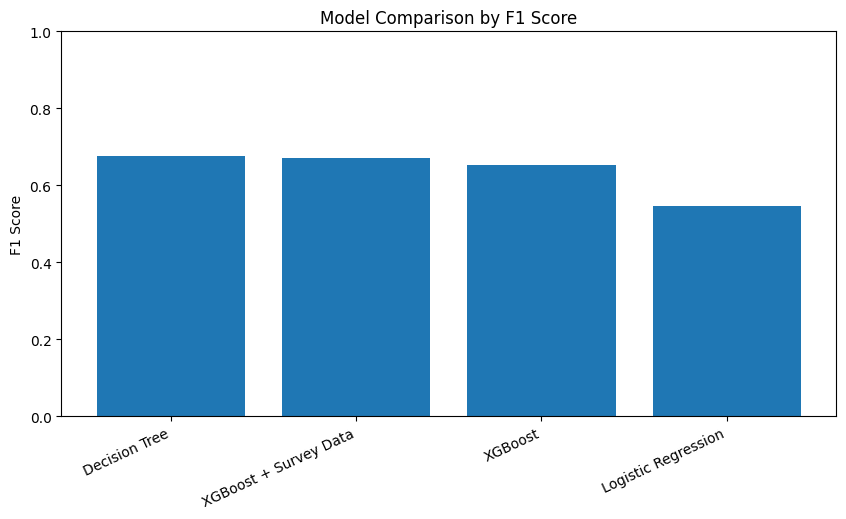

In [11]:
plt.figure(figsize=(10, 5))
plt.bar(results_df['Model'], results_df['F1 Score'])
plt.title('Model Comparison by F1 Score')
plt.ylabel('F1 Score')
plt.xticks(rotation=25, ha='right')
plt.ylim(0, 1)
plt.show()

#### **Step 9: Review Confusion Matrices**

Confusion matrices show how many students were correctly and incorrectly classified. This is useful for understanding the tradeoff between missed dropout cases and students who may be flagged even though they remain enrolled.

In [12]:
for model_name, model_info in models.items():
    cm = confusion_matrix(model_info['y_test'], predictions[model_name])
    cm_df = pd.DataFrame(
        cm,
        index=['Actual Enrolled', 'Actual Departed'],
        columns=['Predicted Enrolled', 'Predicted Departed']
    )
    print()
    print(model_name)
    display(cm_df)


Logistic Regression


,Predicted Enrolled,Predicted Departed
Actual Enrolled,3757,759
Actual Departed,225,595



Decision Tree


,Predicted Enrolled,Predicted Departed
Actual Enrolled,4199,317
Actual Departed,238,582



XGBoost


,Predicted Enrolled,Predicted Departed
Actual Enrolled,4092,424
Actual Departed,217,603



XGBoost + Survey Data


,Predicted Enrolled,Predicted Departed
Actual Enrolled,4153,363
Actual Departed,223,597


## Part 2: Evaluate Prediction Results by Gender

#### **Step 10: Compare Model Performance by Gender**

After reviewing overall performance, the next step is to evaluate results separately for each gender group. This helps identify whether the same model performs differently across groups.

In [13]:
def subgroup_metrics(y_true, y_pred, y_prob):
    auc_value = np.nan
    if pd.Series(y_true).nunique() == 2:
        auc_value = roc_auc_score(y_true, y_prob)

    return {
        'Students': len(y_true),
        'Departure Rate': np.mean(y_true),
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1 Score': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': auc_value
    }

gender_results = []

for model_name, model_info in models.items():
    y_true = pd.Series(model_info['y_test']).reset_index(drop=True)
    y_pred = pd.Series(predictions[model_name])
    y_prob = pd.Series(probabilities[model_name])
    gender_values = test_df['GENDER'].reset_index(drop=True)

    for gender in sorted(gender_values.dropna().unique()):
        mask = gender_values == gender
        metrics = subgroup_metrics(y_true[mask], y_pred[mask], y_prob[mask])
        metrics['Model'] = model_name
        metrics['Gender'] = gender
        gender_results.append(metrics)

gender_results_df = pd.DataFrame(gender_results)
gender_results_df = gender_results_df[['Model', 'Gender', 'Students', 'Departure Rate', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']]
gender_results_df.round(3)

,Model,Gender,Students,Departure Rate,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,Female,3261,0.144,0.820,0.423,0.697,0.527,0.827
1,Logistic Regression,Male,2075,0.170,0.808,0.461,0.764,0.575,0.860
2,Decision Tree,Female,3261,0.144,0.902,0.652,0.673,0.662,0.853
3,Decision Tree,Male,2075,0.170,0.887,0.642,0.759,0.695,0.885
4,XGBoost,Female,3261,0.144,0.883,0.577,0.705,0.635,0.855
5,XGBoost,Male,2075,0.170,0.874,0.600,0.776,0.677,0.886
6,XGBoost + Survey Data,Female,3261,0.144,0.893,0.611,0.692,0.649,0.851
7,XGBoost + Survey Data,Male,2075,0.170,0.886,0.635,0.776,0.698,0.877


#### **Step 11: Visualize Gender-Level Recall**

Recall by gender shows how well each model identifies students who actually departed within each group. Large differences across groups may indicate that the model needs additional review before being used for decision-making.

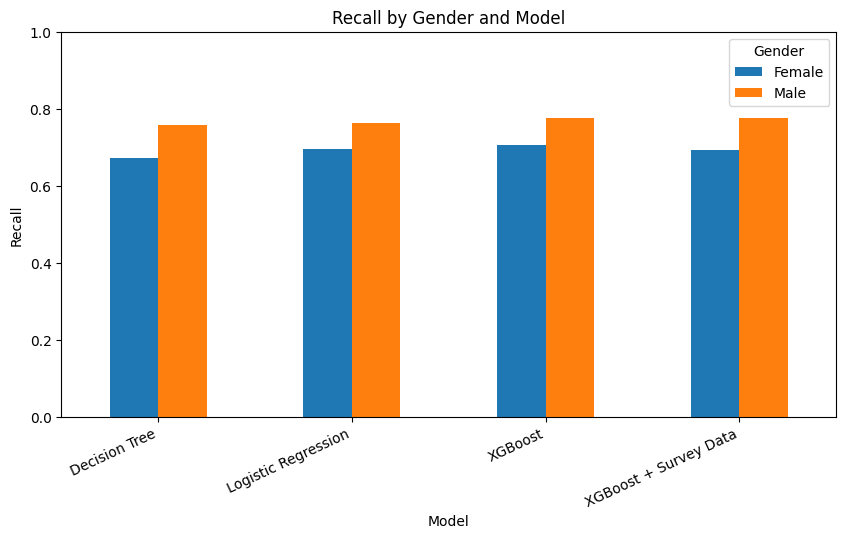

In [14]:
pivot_recall = gender_results_df.pivot(index='Model', columns='Gender', values='Recall')
pivot_recall.plot(kind='bar', figsize=(10, 5))
plt.title('Recall by Gender and Model')
plt.ylabel('Recall')
plt.ylim(0, 1)
plt.xticks(rotation=25, ha='right')
plt.legend(title='Gender')
plt.show()

#### **Step 12: Select a Model for Risk Review**

The model with the highest F1 score is selected for the risk review section. This balances precision and recall while keeping the final workflow simple and consistent.

In [15]:
best_model_name = results_df.iloc[0]['Model']
best_probabilities = probabilities[best_model_name]
best_predictions = predictions[best_model_name]

print('Selected model:', best_model_name)
print()
print('Classification report:')
print(classification_report(y_test, best_predictions, target_names=['Enrolled', 'Departed'], zero_division=0))

Selected model: Decision Tree

Classification report:
              precision    recall  f1-score   support

    Enrolled       0.95      0.93      0.94      4516
    Departed       0.65      0.71      0.68       820

    accuracy                           0.90      5336
   macro avg       0.80      0.82      0.81      5336
weighted avg       0.90      0.90      0.90      5336



## Part 3: Interpret Model Signals

#### **Step 13: Review Important Predictors**

Feature importance helps explain which variables contributed most to the model predictions. For tree-based models, importance values come directly from the trained model. For Logistic Regression, coefficient magnitude is used as a simple indicator of influence.

In [16]:
def get_feature_importance(model_name):
    model = trained_models[model_name]

    if model_name == 'Logistic Regression':
        feature_names = X_train_regular.columns
        coefficients = model.named_steps['classifier'].coef_[0]
        importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': np.abs(coefficients)
        })
    elif model_name == 'XGBoost + Survey Data':
        feature_names = X_train_survey.columns
        importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': model.feature_importances_
        })
    else:
        feature_names = X_train_regular.columns
        importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': model.feature_importances_
        })

    return importance_df.sort_values('Importance', ascending=False).head(15)

importance_df = get_feature_importance(best_model_name)
importance_df

,Feature,Importance
9,TOTAL_UNITS_COMPLETED,0.599939
2,GPA_2,0.227071
6,UNITS_COMPLETED_2,0.073808
10,COMPLETION_RATE_1,0.042947
12,OVERALL_COMPLETION_RATE,0.018081
4,UNITS_ATTEMPTED_2,0.012096
1,GPA_1,0.010043
0,HS_GPA,0.005136
11,COMPLETION_RATE_2,0.003748
8,TOTAL_UNITS_ATTEMPTED,0.002606


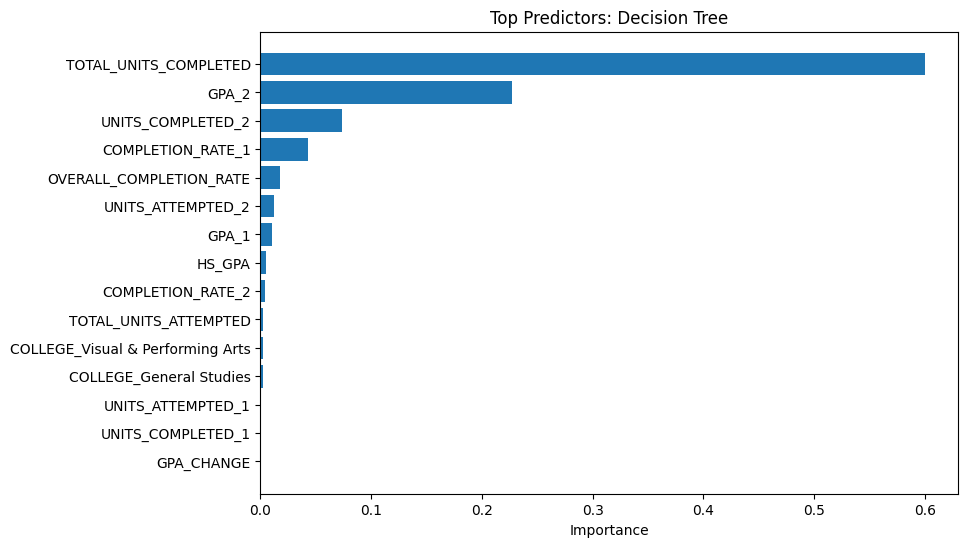

In [17]:
plt.figure(figsize=(9, 6))
plt.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1])
plt.title(f'Top Predictors: {best_model_name}')
plt.xlabel('Importance')
plt.show()

#### **Step 14: Examine Survey Feature Contribution**

When the survey-enhanced model is reviewed, the survey/text components can show whether student feedback adds useful predictive information beyond academic records alone.

In [18]:
survey_importance = get_feature_importance('XGBoost + Survey Data')
survey_feature_importance = survey_importance[survey_importance['Feature'].str.startswith('TEXT_PC')]

if len(survey_feature_importance) > 0:
    display(survey_feature_importance)
else:
    print('No survey text components appeared in the top 15 predictors.')

,Feature,Importance
36,TEXT_PC18,0.012161
33,TEXT_PC15,0.011650
24,TEXT_PC6,0.011580
26,TEXT_PC8,0.011017
42,TEXT_PC24,0.010952
47,TEXT_PC29,0.010929


## Part 4: Explore Student Patterns with Unsupervised Learning

#### **Step 15: Build Student Clusters Without the Outcome Label**

Unsupervised learning can reveal natural student groupings without using the dropout label. This section uses PCA for two-dimensional visualization and K-Means to group students based on their academic and demographic feature patterns.

In [19]:
scaler = StandardScaler()
X_unsupervised = scaler.fit_transform(X_train_regular)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_components = pca.fit_transform(X_unsupervised)

kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_unsupervised)

cluster_df = pd.DataFrame({
    'PC1': pca_components[:, 0],
    'PC2': pca_components[:, 1],
    'Cluster': cluster_labels,
    'Gender': train_df['GENDER'].reset_index(drop=True),
    'Departed': train_df['DEPARTED'].reset_index(drop=True)
})

cluster_df.head()

,PC1,PC2,Cluster,Gender,Departed
0,2.682431,-0.263064,2,Female,0
1,-0.033490,-0.213624,1,Female,0
2,2.772191,-0.208401,2,Female,0
3,-4.701236,-1.177301,0,Female,0
4,1.075148,0.278719,2,Male,0


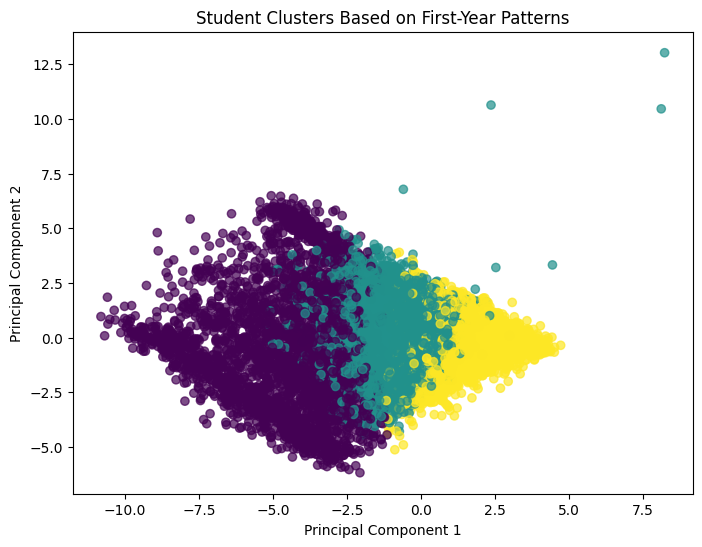

In [20]:
plt.figure(figsize=(8, 6))
plt.scatter(cluster_df['PC1'], cluster_df['PC2'], c=cluster_df['Cluster'], alpha=0.7)
plt.title('Student Clusters Based on First-Year Patterns')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

#### **Step 16: Summarize Clusters by Dropout Rate and Gender**

Cluster summaries help connect unsupervised learning results back to student support planning. A cluster with a higher departure rate may represent a group of students who need earlier or more intensive support.

In [21]:
cluster_summary = (
    cluster_df.groupby('Cluster')
    .agg(
        Students=('Cluster', 'size'),
        Departure_Rate=('Departed', 'mean')
    )
    .reset_index()
)
cluster_summary['Departure_Rate'] = cluster_summary['Departure_Rate'].round(3)
cluster_summary

,Cluster,Students,Departure_Rate
0,0,3445,0.468
1,1,6591,0.086
2,2,9808,0.046


In [22]:
cluster_gender_summary = pd.crosstab(cluster_df['Cluster'], cluster_df['Gender'], normalize='index')
cluster_gender_summary.round(3)

Gender,Female,Male
Cluster,,
0,0.523,0.477
1,0.608,0.392
2,0.619,0.381


# Deploy

## Turning Predictions into Action

#### **Step 17: Create Risk Tiers**

Predicted probabilities are converted into risk tiers so the results can be reviewed in a format that is easier for advisors and student success teams to use.

In [23]:
def assign_risk_tier(probability):
    if probability >= 0.70:
        return 'High Risk'
    elif probability >= 0.40:
        return 'Moderate Risk'
    else:
        return 'Low Risk'

risk_review_df = test_df[['GENDER', 'SEM_3_STATUS', 'DEPARTED']].copy()
risk_review_df['Predicted_Dropout_Probability'] = best_probabilities
risk_review_df['Predicted_Risk_Tier'] = risk_review_df['Predicted_Dropout_Probability'].apply(assign_risk_tier)
risk_review_df['Predicted_Departed'] = best_predictions

risk_review_df.head()

,GENDER,SEM_3_STATUS,DEPARTED,Predicted_Dropout_Probability,Predicted_Risk_Tier,Predicted_Departed
0,Female,E,0,0.158854,Low Risk,0
1,Female,E,0,0.253887,Low Risk,0
2,Male,E,0,0.158854,Low Risk,0
3,Male,E,0,0.253887,Low Risk,0
4,Male,E,0,0.693704,Moderate Risk,1


#### **Step 18: Summarize Risk Tiers by Gender**

A gender-level risk tier summary helps the institution understand how many students are being flagged in each group and whether the distribution of risk tiers requires additional review.

In [24]:
risk_tier_summary = pd.crosstab(
    risk_review_df['GENDER'],
    risk_review_df['Predicted_Risk_Tier'],
    normalize='index'
).round(3)

risk_tier_summary

Predicted_Risk_Tier,High Risk,Low Risk,Moderate Risk
GENDER,,,
Female,0.104,0.761,0.136
Male,0.136,0.690,0.173


#### **Step 19: Draft Intervention Recommendations**

The final step is to connect risk tiers to potential intervention actions. These recommendations should support human decision-making and should be reviewed alongside advising notes, student context, and institutional policy.

In [25]:
intervention_recommendations = pd.DataFrame({
    'Risk Tier': ['High Risk', 'Moderate Risk', 'Low Risk'],
    'Suggested Action': [
        'Prioritize proactive advising, academic planning, and outreach within the next advising cycle.',
        'Offer targeted check-ins, tutoring referrals, and review of first-year academic progress.',
        'Continue standard monitoring and provide general success resources.'
    ]
})

intervention_recommendations

,Risk Tier,Suggested Action
0,High Risk,"Prioritize proactive advising, academic planni..."
1,Moderate Risk,"Offer targeted check-ins, tutoring referrals, ..."
2,Low Risk,Continue standard monitoring and provide gener...


#### **Step 20: Final Summary for Stakeholders**

The summary combines model performance, gender-level evaluation, survey-enhanced modeling, and unsupervised learning insights. A responsible deployment plan should use these results as decision support rather than as an automatic decision-making system.

In [26]:
summary = {
    'Selected Model': best_model_name,
    'Best F1 Score': results_df.loc[results_df['Model'] == best_model_name, 'F1 Score'].iloc[0],
    'Best Recall': results_df.loc[results_df['Model'] == best_model_name, 'Recall'].iloc[0],
    'Best ROC-AUC': results_df.loc[results_df['Model'] == best_model_name, 'ROC-AUC'].iloc[0],
    'High Risk Students Flagged': (risk_review_df['Predicted_Risk_Tier'] == 'High Risk').sum(),
    'Moderate Risk Students Flagged': (risk_review_df['Predicted_Risk_Tier'] == 'Moderate Risk').sum()
}

pd.DataFrame([summary]).round(3)

,Selected Model,Best F1 Score,Best Recall,Best ROC-AUC,High Risk Students Flagged,Moderate Risk Students Flagged
0,Decision Tree,0.677,0.71,0.867,622,802


## Final Report

Summarize the results of your analysis by reflecting on model performance, gender-based evaluation, survey data integration, and the potential use of unsupervised learning in student success initiatives.

Use the guiding questions below to organize your findings.

### 1. Model Performance Comparison

Compare the performance of Logistic Regression, Decision Tree, XGBoost, and XGBoost with Survey Data.

Consider questions such as:

- Which model achieved the strongest overall performance?
- Which evaluation metrics were most helpful in comparing the models?
- Did incorporating survey data improve predictive performance?

### 2. Gender-Based Prediction Analysis

Review the prediction results for male and female students.

Consider the following:

- Did any model perform better for one gender than the other?
- Were there noticeable differences in prediction accuracy or recall across gender groups?
- What factors might contribute to these differences?

### 3. Insights from Unsupervised Learning

Reflect on the clustering analysis completed in this project.

Think about:

- What characteristics distinguished the student clusters?
- Did the clusters reveal meaningful patterns related to student success or dropout risk?
- How could these clusters support institutional decision-making?

### 4. Recommendations

Based on your analysis, provide recommendations for institutional leaders.

Your recommendations may include:

- Which predictive model should be considered for implementation?
- How can survey information strengthen student support efforts?
- How can gender-specific insights inform intervention strategies?
- How might clustering be used alongside predictive models to improve early intervention programs?